## Offline RAG Evaluation 

Till now, we evaluated only the retrieval search engine. Now, we will evaluate the full RAG workflow in offline.

We will use the ground truth FAQ document and response from RAG to compare their similarity using cosine simlarity score.

In [1]:
# Loading the F&Q document with ID's 

import json 

file_location = "/workspaces/LLM-Zoomcamp/02. Evaluation/search_evaluation/docs_with_ids.json"

documents = json.load(open(file_location, "r"))

documents[:2]

[{'text': "The purpose of this document is to capture frequently asked technical questions\nThe exact day and hour of the course will be 15th Jan 2024 at 17h00. The course will start with the first  “Office Hours'' live.1\nSubscribe to course public Google Calendar (it works from Desktop only).\nRegister before the course starts using this link.\nJoin the course Telegram channel with announcements.\nDon’t forget to register in DataTalks.Club's Slack and join the channel.",
  'section': 'General course-related questions',
  'question': 'Course - When will the course start?',
  'course': 'data-engineering-zoomcamp',
  'id': 'c02e79ef'},
 {'text': 'GitHub - DataTalksClub data-engineering-zoomcamp#prerequisites',
  'section': 'General course-related questions',
  'question': 'Course - What are the prerequisites for this course?',
  'course': 'data-engineering-zoomcamp',
  'id': '1f6520ca'}]

Loading the ground truth dataset which is created already and we will filter the questions related to ML Zommcamp only.

In [2]:
import pandas as pd

ground_truth_data_url = "/workspaces/LLM-Zoomcamp/02. Evaluation/search_evaluation/ground-truth-data.csv"
df_ground_truth = pd.read_csv(ground_truth_data_url)
df_ground_truth = df_ground_truth[df_ground_truth["course"] == "machine-learning-zoomcamp"]

ground_truth_data = df_ground_truth.to_dict(orient="records")


In [3]:
ground_truth_data[:2]

[{'question': 'Where can I sign up for the course?',
  'course': 'machine-learning-zoomcamp',
  'document': '0227b872'},
 {'question': 'Can you provide a link to sign up?',
  'course': 'machine-learning-zoomcamp',
  'document': '0227b872'}]

In [4]:
# savings all the indexes of the documents 

doc_idx = {d["id"]: d for d in documents}
doc_idx["0227b872"]["text"]

'Machine Learning Zoomcamp FAQ\nThe purpose of this document is to capture frequently asked technical questions.\nWe did this for our data engineering course and it worked quite well. Check this document for inspiration on how to structure your questions and answers:\nData Engineering Zoomcamp FAQ\nIn the course GitHub repository there’s a link. Here it is: https://airtable.com/shryxwLd0COOEaqXo\nwork'

### Indexing data using MinSearch (vector method)

We will index the documents using `sentence transformers` through vector search in MinSearch package.

This function is to retreive the search results for given query and then passed to RAG (LLM model) using relevant prompt.

In [5]:
from sentence_transformers import SentenceTransformer

model_name = "multi-qa-MiniLM-L6-cos-v1"
model = SentenceTransformer(model_name)

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# generating vectors for the documents
from tqdm.auto import tqdm

vectors = []

for doc in tqdm(documents):
    question = doc["question"]
    text = doc["text"]
    vector = model.encode(question + " " + text)  # encoding both question & text together
    vectors.append(vector)


100%|██████████| 948/948 [00:44<00:00, 21.24it/s]


In [ ]:
# converting to numpy array for efficient storage

import numpy as np

vectors = np.array(vectors)

In [8]:
vectors[0]

array([-2.47414540e-02,  1.25250276e-02,  1.86790135e-02, -2.44598254e-03,
       -6.29659742e-02, -1.47205254e-03, -9.39881280e-02, -7.70688951e-02,
       -2.42589507e-02, -2.65896064e-03, -3.13756540e-02,  2.58985683e-02,
        1.27621504e-04,  1.16573623e-03,  5.24657499e-03, -2.75482722e-02,
        1.25110997e-02, -1.48042336e-01,  3.98083031e-02, -7.59841409e-03,
        8.63104872e-03, -1.18885543e-02, -2.55144592e-02,  3.24880444e-02,
        2.93857064e-02,  1.58539917e-02,  2.06907615e-02, -2.25544237e-02,
        5.48142008e-02,  9.73003265e-03,  2.40406208e-02, -7.03245550e-02,
        8.46367925e-02,  5.13699763e-02, -8.63983389e-03,  5.17790839e-02,
        4.36919183e-02, -4.95563671e-02,  4.17245738e-02,  8.60651284e-02,
       -2.01458577e-02, -9.76669937e-02, -4.44233380e-02,  4.23669964e-02,
        1.40459672e-01, -4.54986468e-03, -9.79090482e-03, -5.90606630e-02,
        1.28405672e-02,  2.20494047e-02, -1.69678740e-02, -7.27972835e-02,
       -3.53072956e-02,  

In [8]:
# fitting the index to MinSearch's vector Index 

from minsearch import VectorSearch

vindex = VectorSearch(keyword_fields=["course"])
vindex.fit(vectors, documents)

#### Retreival search function 

In [9]:
def minsearch_vector_search(vector, course):
    # returns top 5 results for the given vector and course
    return vindex.search(
        vector,
        filter_dict={"course": course},
        num_results=5
    )


def question_text_vector(query):
    # encodes the question and returns the vector to vector search function
    question = query["question"]
    course = query["course"]
    vector_query = model.encode(question)

    return minsearch_vector_search(vector_query, course)


In [10]:
# sample response

question_text_vector(dict(
    question='Are sessions recorded if I miss one?',
    course='machine-learning-zoomcamp'
))

[{'text': 'Everything is recorded, so you won’t miss anything. You will be able to ask your questions for office hours in advance and we will cover them during the live stream. Also, you can always ask questions in Slack.',
  'section': 'General course-related questions',
  'question': 'What if I miss a session?',
  'course': 'machine-learning-zoomcamp',
  'id': '5170565b'},
 {'text': 'The course videos are pre-recorded, you can start watching the course right now.\nWe will also occasionally have office hours - live sessions where we will answer your questions. The office hours sessions are recorded too.\nYou can see the office hours as well as the pre-recorded course videos in the course playlist on YouTube.',
  'section': 'General course-related questions',
  'question': 'Is it going to be live? When?',
  'course': 'machine-learning-zoomcamp',
  'id': '39fda9f0'},
 {'text': "Problem description\nThe accuracy and the loss are both still the same or nearly the same while training.\nSol

### RAG Workflow 

In here, we will use previously defined retrieval search engine along with LLM through a prompt to genrate final response for a given query.

In [11]:
def build_prompt(query, search_results):
    prompt_template = """
You're a course teaching assistant. Answer the QUESTION based on the CONTEXT from the FAQ database.
Use only the facts from the CONTEXT when answering the QUESTION.

QUESTION: {question}

CONTEXT: 
{context}
""".strip()

    context = ""
    
    for doc in search_results:
        context = context + f"section: {doc['section']}\nquestion: {doc['question']}\nanswer: {doc['text']}\n\n"
    
    prompt = prompt_template.format(question=query, context=context).strip()
    return prompt

In [ ]:
from openai import OpenAI

OPEN_AI_API_KEY = "use_your_own_key"  # replace with your OpenAI API key
client = OpenAI(api_key=OPEN_AI_API_KEY)

In [7]:
def llm(prompt, model="gpt-4o"):
    response = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}]
    )
    
    return response.choices[0].message.content

In [8]:
# final RAG workflow 

def rag_workflow(query: dict, model: str ="gpt-4o"):
    search_results = question_text_vector(query)
    prompt = build_prompt(query["question"], search_results)
    answer = llm(prompt, model=model)
    return answer

In [15]:
ground_truth_data[15]

{'question': 'How much theoretical content is there in the course?',
 'course': 'machine-learning-zoomcamp',
 'document': 'ecca790c'}

In [16]:
rag_workflow(ground_truth_data[15])

'The course contains the bare minimum of theoretical content, with a focus more on practical application. Theory is covered only on an intuitive level. For instance, the course will not delve into deriving the gradient update rule for logistic regression, but will instead focus on how to use logistic regression and interpret the results.'

In [17]:
# the actual answer from FAQ

doc_idx['ecca790c']['text']

"The bare minimum. The focus is more on practice, and we'll cover the theory only on the intuitive level.: https://mlbookcamp.com/article/python\nFor example, we won't derive the gradient update rule for logistic regression (there are other great courses for that), but we'll cover how to use logistic regression and make sense of the results."

### Evaluation using Cosine Similarity metric 

First we will see a sample for evaluating this metric.

In [18]:
original_answer = "The bare minimum. The focus is more on practice, and we'll cover the theory only on the intuitive level.: https://mlbookcamp.com/article/python\nFor example, we won't derive the gradient update rule for logistic regression (there are other great courses for that), but we'll cover how to use logistic regression and make sense of the results."
rag_answer = "he course contains the bare minimum of theoretical content, with a focus more on practical application. Theory is covered only at an intuitive level, and not in detail, such as deriving complex formulas."

vector_orginal = model.encode(original_answer)
vector_rag = model.encode(rag_answer)

vector_orginal.dot(vector_rag)

np.float32(0.3697315)

> We will compare the scores of multiple RAG flow (bu changing different LLM model like gpt4, gpt4o etc..) to see which model performs better. 

In [20]:
ground_truth_data[0]

{'question': 'Where can I sign up for the course?',
 'course': 'machine-learning-zoomcamp',
 'document': '0227b872'}

In [21]:
doc_idx["0227b872"]

{'text': 'Machine Learning Zoomcamp FAQ\nThe purpose of this document is to capture frequently asked technical questions.\nWe did this for our data engineering course and it worked quite well. Check this document for inspiration on how to structure your questions and answers:\nData Engineering Zoomcamp FAQ\nIn the course GitHub repository there’s a link. Here it is: https://airtable.com/shryxwLd0COOEaqXo\nwork',
 'section': 'General course-related questions',
 'question': 'How do I sign up?',
 'course': 'machine-learning-zoomcamp',
 'id': '0227b872'}

**Let's save original answer, doc id and RAG generated answer for gpt-3.5-turbo model.**

For higher models like GPT-4, GPT-4o etc.. OPEN AI API cost may increase.

In [22]:
answers = {}

In [ ]:

for i, rec in enumerate(tqdm(ground_truth_data)):
    if i in answers:
        continue

    try:
        answer_llm = rag_workflow(rec, model="gpt-3.5-turbo")
        doc_id = rec["document"]
        original_answer = doc_idx[doc_id]["text"]

        answers[i] = {
            "answer_llm": answer_llm,
            "orig_answer": original_answer,
            "document": doc_id,
            "question": rec["question"],
            "course": rec["course"]
        }

    except Exception as e:
        print(f"Error for record {i}: {e}")

`Note:` It may take more time to run the code. Get the output file from author for learning purposes. Parallel execution may decrease the time but the cost remains same.

In [28]:
# Parallel execution using Multi Threading code 

from tqdm.auto import tqdm

from concurrent.futures import ThreadPoolExecutor

pool = ThreadPoolExecutor(max_workers=5)  # Adjust max_workers based on your system

def map_progress(pool, seq, func):
    results = []

    with tqdm(total=len(seq)) as progress:
        futures = []

        for query in seq:
            future = pool.submit(func, query)
            future.add_done_callback(lambda p: progress.update()) # updating the progress bar
            futures.append(future)

            for future in futures:
                result = future.result()
                results.append(result)

    return results
        

In [29]:
def process_record(rec):
    model = 'gpt-3.5-turbo'
    answer_llm = rag_workflow(rec, model=model)
    
    doc_id = rec['document']
    original_doc = doc_idx[doc_id]
    answer_orig = original_doc['text']

    return {
        'answer_llm': answer_llm,
        'answer_orig': answer_orig,
        'document': doc_id,
        'question': rec['question'],
        'course': rec['course'],
    }

> Saving the answers from Author repository for models starting from GPT4 etc..

In [9]:
# answers

results_gpt4o_df = pd.read_csv("https://raw.githubusercontent.com/DataTalksClub/llm-zoomcamp/refs/heads/main/03-evaluation/rag_evaluation/data/results-gpt4o.csv")
results_gpt4o_df.head()

,answer_llm,answer_orig,document,question,course
0,The CONTEXT provided does not give specific in...,Machine Learning Zoomcamp FAQ\nThe purpose of ...,0227b872,Where can I sign up for the course?,machine-learning-zoomcamp
1,You can sign up for the Machine Learning Zoomc...,Machine Learning Zoomcamp FAQ\nThe purpose of ...,0227b872,Can you provide a link to sign up?,machine-learning-zoomcamp
2,"Yes, there is an FAQ for the Machine Learning ...",Machine Learning Zoomcamp FAQ\nThe purpose of ...,0227b872,Is there an FAQ for this Machine Learning course?,machine-learning-zoomcamp
3,"No, the provided context does not include any ...",Machine Learning Zoomcamp FAQ\nThe purpose of ...,0227b872,Does this course have a GitHub repository for ...,machine-learning-zoomcamp
4,To structure your questions and answers for th...,Machine Learning Zoomcamp FAQ\nThe purpose of ...,0227b872,How can I structure my questions and answers f...,machine-learning-zoomcamp


In [27]:
results_gpt4o_df.to_csv("data/results-gpt4o.csv", index=False)

In [30]:
# running for GPT-3.5 Turbo model in parallel excecution as it costs less

# calling the map_progress function to process the records in parallel
results_gpt35_turbo = map_progress(pool, ground_truth_data, process_record)


100%|██████████| 1830/1830 [22:48<00:00,  1.34it/s]


In [42]:
results_gpt35_turbo[0]

{'answer_llm': 'You can sign up for the course by going to the course page at http://mlzoomcamp.com/. Scroll down to access the course materials and start going through them. Make sure to read everything in the cohort folder for your cohort’s year as well.',
 'answer_orig': 'Machine Learning Zoomcamp FAQ\nThe purpose of this document is to capture frequently asked technical questions.\nWe did this for our data engineering course and it worked quite well. Check this document for inspiration on how to structure your questions and answers:\nData Engineering Zoomcamp FAQ\nIn the course GitHub repository there’s a link. Here it is: https://airtable.com/shryxwLd0COOEaqXo\nwork',
 'document': '0227b872',
 'question': 'Where can I sign up for the course?',
 'course': 'machine-learning-zoomcamp'}

In [3]:
import pandas as pd

In [10]:
# saving the answers

results_gpt35_df = pd.read_csv("https://raw.githubusercontent.com/DataTalksClub/llm-zoomcamp/refs/heads/main/03-evaluation/rag_evaluation/data/results-gpt35.csv")
results_gpt35_df.to_csv("data/results-gpt35.csv", index=False)

### Cosine similarity

A -> Q -> A'

Where `Q` is genrated question from the known answer. `A'` is the RAG generated answer for that question.

cosine(A, A')

In [9]:
results_gpt4o_df.head()

,answer_llm,answer_orig,document,question,course
0,The CONTEXT provided does not give specific in...,Machine Learning Zoomcamp FAQ\nThe purpose of ...,0227b872,Where can I sign up for the course?,machine-learning-zoomcamp
1,You can sign up for the Machine Learning Zoomc...,Machine Learning Zoomcamp FAQ\nThe purpose of ...,0227b872,Can you provide a link to sign up?,machine-learning-zoomcamp
2,"Yes, there is an FAQ for the Machine Learning ...",Machine Learning Zoomcamp FAQ\nThe purpose of ...,0227b872,Is there an FAQ for this Machine Learning course?,machine-learning-zoomcamp
3,"No, the provided context does not include any ...",Machine Learning Zoomcamp FAQ\nThe purpose of ...,0227b872,Does this course have a GitHub repository for ...,machine-learning-zoomcamp
4,To structure your questions and answers for th...,Machine Learning Zoomcamp FAQ\nThe purpose of ...,0227b872,How can I structure my questions and answers f...,machine-learning-zoomcamp


In [10]:
results_gpt40 = results_gpt4o_df.to_dict(orient="records")
results_gpt40[0]

{'answer_llm': 'The CONTEXT provided does not give specific instructions on how to sign up for the course. However, it does mention that you can access the course materials on the course page: [ML Zoomcamp](http://mlzoomcamp.com/). \n\nYou might want to start by visiting the course website and looking for further instructions there, as it likely has additional details on how to sign up or enroll in the course.',
 'answer_orig': 'Machine Learning Zoomcamp FAQ\nThe purpose of this document is to capture frequently asked technical questions.\nWe did this for our data engineering course and it worked quite well. Check this document for inspiration on how to structure your questions and answers:\nData Engineering Zoomcamp FAQ\nIn the course GitHub repository there’s a link. Here it is: https://airtable.com/shryxwLd0COOEaqXo\nwork',
 'document': '0227b872',
 'question': 'Where can I sign up for the course?',
 'course': 'machine-learning-zoomcamp'}

In [11]:
results_gpt35_df.head()

,answer_llm,answer_orig,document,question,course
0,You can sign up for the course by going to the...,Machine Learning Zoomcamp FAQ\nThe purpose of ...,0227b872,Where can I sign up for the course?,machine-learning-zoomcamp
1,"I am sorry, but there is no direct link provid...",Machine Learning Zoomcamp FAQ\nThe purpose of ...,0227b872,Can you provide a link to sign up?,machine-learning-zoomcamp
2,"Yes, there is an FAQ for the Machine Learning ...",Machine Learning Zoomcamp FAQ\nThe purpose of ...,0227b872,Is there an FAQ for this Machine Learning course?,machine-learning-zoomcamp
3,"No, the course does not have a GitHub reposito...",Machine Learning Zoomcamp FAQ\nThe purpose of ...,0227b872,Does this course have a GitHub repository for ...,machine-learning-zoomcamp
4,Based on the information provided in the FAQ d...,Machine Learning Zoomcamp FAQ\nThe purpose of ...,0227b872,How can I structure my questions and answers f...,machine-learning-zoomcamp


In [12]:
results_gpt35 = results_gpt35_df.to_dict(orient="records")
results_gpt35[0]

{'answer_llm': 'You can sign up for the course by going to the course page at http://mlzoomcamp.com/ and scrolling down to access the course materials.',
 'answer_orig': 'Machine Learning Zoomcamp FAQ\nThe purpose of this document is to capture frequently asked technical questions.\nWe did this for our data engineering course and it worked quite well. Check this document for inspiration on how to structure your questions and answers:\nData Engineering Zoomcamp FAQ\nIn the course GitHub repository there’s a link. Here it is: https://airtable.com/shryxwLd0COOEaqXo\nwork',
 'document': '0227b872',
 'question': 'Where can I sign up for the course?',
 'course': 'machine-learning-zoomcamp'}

In [13]:
def compute_cosine_similarity(record):
    # computes cosine similarity between original and LLM answer

    answer_orig = record["answer_orig"]
    answer_llm = record["answer_llm"]

    v_llm = model.encode(answer_llm) # encoding the text into vector
    v_orig = model.encode(answer_orig)

    return v_llm.dot(v_orig) / (np.linalg.norm(v_llm) * np.linalg.norm(v_orig)) 
    

In [15]:
from tqdm.auto import tqdm

#### GPT-4o Evaluation 

In [16]:
similarity_scores = []

for record in tqdm(results_gpt40):
    score = compute_cosine_similarity(record)
    similarity_scores.append(score)


100%|██████████| 1830/1830 [02:35<00:00, 11.74it/s]


In [17]:
results_gpt4o_df["cosine_similarity"] = similarity_scores
results_gpt4o_df

,answer_llm,answer_orig,document,question,course,cosine_similarity
0,The CONTEXT provided does not give specific in...,Machine Learning Zoomcamp FAQ\nThe purpose of ...,0227b872,Where can I sign up for the course?,machine-learning-zoomcamp,0.534533
1,You can sign up for the Machine Learning Zoomc...,Machine Learning Zoomcamp FAQ\nThe purpose of ...,0227b872,Can you provide a link to sign up?,machine-learning-zoomcamp,0.696121
2,"Yes, there is an FAQ for the Machine Learning ...",Machine Learning Zoomcamp FAQ\nThe purpose of ...,0227b872,Is there an FAQ for this Machine Learning course?,machine-learning-zoomcamp,0.717514
3,"No, the provided context does not include any ...",Machine Learning Zoomcamp FAQ\nThe purpose of ...,0227b872,Does this course have a GitHub repository for ...,machine-learning-zoomcamp,-0.000328
4,To structure your questions and answers for th...,Machine Learning Zoomcamp FAQ\nThe purpose of ...,0227b872,How can I structure my questions and answers f...,machine-learning-zoomcamp,0.387620
...,...,...,...,...,...,...
1825,Some suggested titles for listing the Machine ...,I’ve seen LinkedIn users list DataTalksClub as...,c6a22665,What are some suggested titles for listing the...,machine-learning-zoomcamp,0.789918
1826,It is not advised to list your Machine Learnin...,I’ve seen LinkedIn users list DataTalksClub as...,c6a22665,Should I list the Machine Learning Zoomcamp ex...,machine-learning-zoomcamp,0.781627
1827,You can incorporate your Machine Learning Zoom...,I’ve seen LinkedIn users list DataTalksClub as...,c6a22665,In which LinkedIn sections can I incorporate m...,machine-learning-zoomcamp,0.772360
1828,Ani Mkrtumyan provided the advice on including...,I’ve seen LinkedIn users list DataTalksClub as...,c6a22665,Who gave advice on including a project link in...,machine-learning-zoomcamp,0.337838


In [18]:
results_gpt4o_df["cosine_similarity"].describe()

count    1830.000000
mean        0.679129
std         0.217995
min        -0.153426
25%         0.591460
50%         0.734788
75%         0.835390
max         0.995339
Name: cosine_similarity, dtype: float64

> Cosine similarity ranges from -1 to +1 where +1 is positively related (identical direction), 0 is unrelated and -1 is disimilar.

Also, we notice that mean score of 67% and median score of 73% indicates answers are quite similar.

In [19]:
import seaborn as sns

/tmp/ipykernel_4119/588091041.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(results_gpt4o_df["cosine_similarity"])


<Axes: xlabel='cosine_similarity', ylabel='Density'>

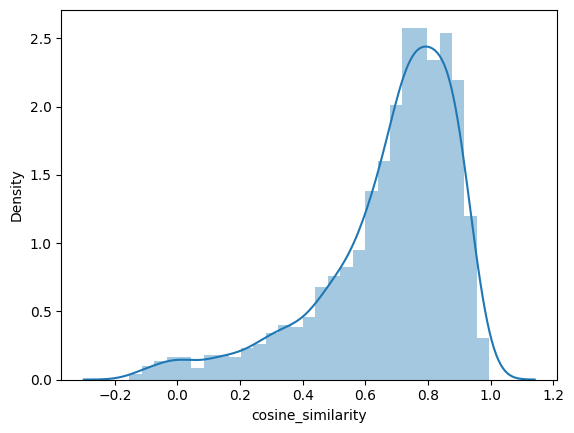

In [22]:
sns.distplot(results_gpt4o_df["cosine_similarity"])

>GPT-4o results are quite satifactory as seen from above distribution most of the answers has score of 55% to 85%


#### GPT-3.5-Turbo evaluation

In [23]:
similarity_scores = []

for record in tqdm(results_gpt35):
    score = compute_cosine_similarity(record)
    similarity_scores.append(score)

100%|██████████| 1830/1830 [01:54<00:00, 16.00it/s]


In [25]:
results_gpt35_df["cosine_similarity"] = similarity_scores

In [26]:
results_gpt35_df["cosine_similarity"].describe()

count    1830.000000
mean        0.657599
std         0.226062
min        -0.168921
25%         0.546505
50%         0.714783
75%         0.817262
max         1.000000
Name: cosine_similarity, dtype: float64

> For GPT-3.5-turbo model we notice that mean score of 65% and median score of 71% indicates answers are quite similar.

In [28]:
from matplotlib import pyplot as plt

/tmp/ipykernel_4119/995130981.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(results_gpt4o_df["cosine_similarity"], label="GPT-4o")
/tmp/ipykernel_4119/995130981.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(results_gpt35_df["cosine_similarity"], label="GPT-3.5-turbo")


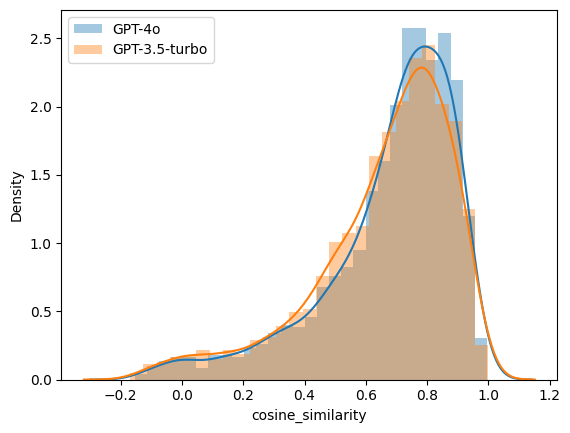

In [30]:
# comparing both results 

sns.distplot(results_gpt4o_df["cosine_similarity"], label="GPT-4o")
sns.distplot(results_gpt35_df["cosine_similarity"], label="GPT-3.5-turbo")

plt.legend()
plt.show()

> Majority of answers are similar with both models but GPT-4o is slightly better compared to 3.5-turbo model. But the price of 3.5 is 10x cheaper and faster than gpt-4o so the former model is better for usage.

### LLM as a Judge

We will use LLM as a judge to evaluate the answers. Built a prompt to mimic LLM as a evaluator in below code.

There are prompt templates where one compares original answer with RAG generated answer and other compare question and RAG generate asnwers. The output of the LLM model will have new column with type of relevance.

In [11]:
prompt1_template = """
You are an expert evaluator for a Retrieval-Augmented Generation (RAG) system.
Your task is to analyze the relevance of the generated answer compared to the original answer provided.
Based on the relevance and similarity of the generated answer to the original answer, you will classify
it as "NON_RELEVANT", "PARTLY_RELEVANT", or "RELEVANT".

Here is the data for evaluation:

Original Answer: {answer_orig}
Generated Question: {question}
Generated Answer: {answer_llm}

Please analyze the content and context of the generated answer in relation to the original
answer and provide your evaluation in parsable JSON without using code blocks:

{{
  "Relevance": "NON_RELEVANT" | "PARTLY_RELEVANT" | "RELEVANT",
  "Explanation": "[Provide a brief explanation for your evaluation]"
}}
""".strip()

prompt2_template = """
You are an expert evaluator for a Retrieval-Augmented Generation (RAG) system.
Your task is to analyze the relevance of the generated answer to the given question.
Based on the relevance of the generated answer, you will classify it
as "NON_RELEVANT", "PARTLY_RELEVANT", or "RELEVANT".

Here is the data for evaluation:

Question: {question}
Generated Answer: {answer_llm}

Please analyze the content and context of the generated answer in relation to the question
and provide your evaluation in parsable JSON without using code blocks:

{{
  "Relevance": "NON_RELEVANT" | "PARTLY_RELEVANT" | "RELEVANT",
  "Explanation": "[Provide a brief explanation for your evaluation]"
}}
""".strip()

> We will just use this evaluation technique on smaller sample of the previously generated data

In [12]:
df_sample = results_gpt35_df.sample(n=100, random_state=1)

In [13]:
samples = df_sample.to_dict(orient="records")

In [14]:
record = samples[0]
record

{'answer_llm': 'The syntax for using precision_recall_fscore_support in Python is:\nfrom sklearn.metrics import precision_recall_fscore_support\nprecision, recall, fscore, support = precision_recall_fscore_support(y_val, y_val_pred, zero_division=0)',
 'answer_orig': 'Scikit-learn offers another way: precision_recall_fscore_support\nExample:\nfrom sklearn.metrics import precision_recall_fscore_support\nprecision, recall, fscore, support = precision_recall_fscore_support(y_val, y_val_pred, zero_division=0)\n(Gopakumar Gopinathan)',
 'document': '403bbdd8',
 'question': 'What is the syntax for using precision_recall_fscore_support in Python?',
 'course': 'machine-learning-zoomcamp'}

In [15]:
prompt = prompt1_template.format(**record)
print(prompt)

You are an expert evaluator for a Retrieval-Augmented Generation (RAG) system.
Your task is to analyze the relevance of the generated answer compared to the original answer provided.
Based on the relevance and similarity of the generated answer to the original answer, you will classify
it as "NON_RELEVANT", "PARTLY_RELEVANT", or "RELEVANT".

Here is the data for evaluation:

Original Answer: Scikit-learn offers another way: precision_recall_fscore_support
Example:
from sklearn.metrics import precision_recall_fscore_support
precision, recall, fscore, support = precision_recall_fscore_support(y_val, y_val_pred, zero_division=0)
(Gopakumar Gopinathan)
Generated Question: What is the syntax for using precision_recall_fscore_support in Python?
Generated Answer: The syntax for using precision_recall_fscore_support in Python is:
from sklearn.metrics import precision_recall_fscore_support
precision, recall, fscore, support = precision_recall_fscore_support(y_val, y_val_pred, zero_division=0)



In [16]:
answer = llm(prompt, model='gpt-4o-mini')
answer

'{\n  "Relevance": "RELEVANT",\n  "Explanation": "The generated answer provides the exact syntax for using \'precision_recall_fscore_support\' in Python, matching the content and context of the original answer. It correctly identifies the method and includes the appropriate code snippet as described, fulfilling the request made by the generated question."\n}'

In [17]:
json.loads(answer)

{'Relevance': 'RELEVANT',
 'Explanation': "The generated answer provides the exact syntax for using 'precision_recall_fscore_support' in Python, matching the content and context of the original answer. It correctly identifies the method and includes the appropriate code snippet as described, fulfilling the request made by the generated question."}

In [19]:
from tqdm.auto import tqdm

evaluations = []

for record in tqdm(samples):
    prompt = prompt1_template.format(**record)
    answer = llm(prompt, model='gpt-4o-mini')
    evaluation = json.loads(answer)

    evaluations.append({
        **evaluation
    })

100%|██████████| 100/100 [02:55<00:00,  1.76s/it]


In [20]:
evaluations[:5]

[{'Relevance': 'RELEVANT',
  'Explanation': 'The generated answer provides the exact syntax for using precision_recall_fscore_support in Python, which directly aligns with the information given in the original answer. The content is consistent and addresses the question appropriately.'},
 {'Relevance': 'RELEVANT',
  'Explanation': 'The generated answer directly addresses the question about modifying scripts to avoid pickle errors when using waitress. It correctly encapsulates the solution provided in the original answer, specifically the need to put the custom column transformer class in a separate module and import it in both scripts. This aligns well with the information given in the original answer.'},
 {'Relevance': 'RELEVANT',
  'Explanation': 'The generated answer directly addresses the question about which command launches a container image in interactive mode by providing the exact command from the original answer. It is contextually and content-wise accurate, making it fully r

In [21]:
df_evaluations = pd.DataFrame(evaluations)
df_evaluations.head()

,Relevance,Explanation
0,RELEVANT,The generated answer provides the exact syntax...
1,RELEVANT,The generated answer directly addresses the qu...
2,RELEVANT,The generated answer directly addresses the qu...
3,RELEVANT,The generated answer directly addresses the qu...
4,NON_RELEVANT,The generated answer discusses a pip version e...


In [22]:
df_evaluations["Relevance"].value_counts(normalize=True)

Relevance
RELEVANT           0.67
PARTLY_RELEVANT    0.23
NON_RELEVANT       0.10
Name: proportion, dtype: float64

> LLM as a Judge also confirms that 67% of answers are similar which is confirmed by our evaluation using cosine similarity aswell.

In [23]:
df_evaluations[df_evaluations.Relevance == 'NON_RELEVANT'] 

,Relevance,Explanation
4,NON_RELEVANT,The generated answer discusses a pip version e...
9,NON_RELEVANT,The generated answer states that there is no i...
11,NON_RELEVANT,The generated answer provides a solution relat...
20,NON_RELEVANT,The generated answer denies the existence of a...
27,NON_RELEVANT,The generated answer does not relate to the AW...
41,NON_RELEVANT,The generated answer is focused on setting up ...
49,NON_RELEVANT,The generated answer fails to address the orig...
58,NON_RELEVANT,The generated answer directly contradicts the ...
90,NON_RELEVANT,The generated answer addresses a different asp...
93,NON_RELEVANT,The generated answer does not address the cont...


In [24]:
samples[4]

{'answer_llm': "The cause of the pip version error in this week's serverless deep learning section might be due to a version conflict in the virtual environment. Make sure to use the same version of Scikit-Learn that was used for training the model.",
 'answer_orig': 'When running docker build -t dino-dragon-model it returns the above error\nThe most common source of this error in this week is because Alex video shows a version of the wheel with python 8, we need to find a wheel with the version that we are working on. In this case python 9. Another common error is to copy the link, this will also produce the same error, we need to download the raw format:\nhttps://github.com/alexeygrigorev/tflite-aws-lambda/raw/main/tflite/tflite_runtime-2.7.0-cp39-cp39-linux_x86_64.whl\nPastor Soto',
 'document': '42c09143',
 'question': "What might be the cause of the pip version error in this week's serverless deep learning section?",
 'course': 'machine-learning-zoomcamp'}

Offline Evaluation of RAG has been discussed in the notebook using below approaches

* Evaluation using Cosine Similarity 
* Evaluation using LLM as a Judge.